# DSM050 Data Visualisation — Midterm Coursework

**Topic:** Global determinants of life expectancy (WHO, 2000–2015)  
**Audience:** Policymakers  
**Dataset:** [WHO Life Expectancy Data](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who) — Kumar Rajarshi (Kaggle mirror of WHO GHO data)

## Research Questions
1. **RQ1** — What is the strongest association between socio-economic and educational indicators in terms of national life expectancy 2000-2015? 
2. **RQ2** — Is the "Developed / Developing" binary that WHO inherited from previous UN classifications a meaningful distinction of health outcome once child mortality, immunisation coverage and HIV/AIDS prevalence are accounted for?
3. **RQ3** — What health-behaviour and disease parameters best differentiate high versus low mortality country-years? 

This notebook contains all preprocessing, EDA and visualisation code. Figures are exported to `figures/` for embedding in the report.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproducibility & style
np.random.seed(42)
sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW  = ROOT / "data" / "raw" / "Life Expectancy Data.csv"
PROC = ROOT / "data" / "processed"
FIG_UNI = ROOT / "figures" / "univariate"
FIG_MUL = ROOT / "figures" / "multivariate"
FIG_DSH = ROOT / "figures" / "dashboard"
for p in (PROC, FIG_UNI, FIG_MUL, FIG_DSH):
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Project root: /Users/annaliskirwa/Documents/Annalis/Master/Data Visualisation/Coursework1


## 1. Load raw data

In [2]:
raw = pd.read_csv(RAW)
print(f"Shape: {raw.shape}")
print(f"Countries: {raw['Country'].nunique()}   Years: {raw['Year'].min()}–{raw['Year'].max()}")
raw.head()

Shape: (2938, 22)
Countries: 193   Years: 2000–2015


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## 2. Data cleaning

Rationale for each step is stated inline — this is important for rubric section 3.

### 2.1 Normalise column names
Several columns contain leading/trailing spaces (e.g. `" BMI"`, `" HIV/AIDS"`, `" thinness  1-19 years"`). Left as-is they cause silent bugs when referenced. We strip whitespace and use `snake_case` for readability.

In [3]:
df = raw.copy()
df.columns = (df.columns.str.strip()
                        .str.lower()
                        .str.replace(r"[ /\-]+", "_", regex=True)
                        .str.replace(r"__+", "_", regex=True))
df = df.rename(columns={
    "life_expectancy":       "life_expectancy",
    "thinness_1_19_years":   "thinness_10_19",
    "thinness_5_9_years":    "thinness_5_9",
    "income_composition_of_resources": "income_index",
    "percentage_expenditure": "pct_expenditure",
    "total_expenditure":     "health_expenditure_pct",
})
print(df.columns.tolist())

['country', 'year', 'status', 'life_expectancy', 'adult_mortality', 'infant_deaths', 'alcohol', 'pct_expenditure', 'hepatitis_b', 'measles', 'bmi', 'under_five_deaths', 'polio', 'health_expenditure_pct', 'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_10_19', 'thinness_5_9', 'income_index', 'schooling']


### 2.2 Missing values

Rows are country–year panels; simple listwise deletion would remove ~40% of records and disproportionately drop lower-income countries (introducing bias). Instead we impute within each country using the country's own time-series median, then fall back to the country's development-status median. This preserves cross-country structure that our RQs depend on.

In [4]:
missing_before = df.isna().sum()
print("Missing before imputation (top 10):")
print(missing_before.sort_values(ascending=False).head(10))

num_cols = df.select_dtypes(include="number").columns.drop("year")

# Step 1: country-level median
df[num_cols] = (df.groupby("country")[num_cols]
                  .transform(lambda s: s.fillna(s.median())))
# Step 2: fallback to status-level median
df[num_cols] = (df.groupby("status")[num_cols]
                  .transform(lambda s: s.fillna(s.median())))
# Step 3: any remaining global median (edge case: country all-NaN for a rare var)
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

missing_after = df.isna().sum()
print(f"\nRemaining missing values: {missing_after.sum()}  (target = 0)")

Missing before imputation (top 10):
population                652
hepatitis_b               553
gdp                       448
health_expenditure_pct    226
alcohol                   194
income_index              167
schooling                 163
thinness_5_9               34
thinness_10_19             34
bmi                        34
dtype: int64



Remaining missing values: 0  (target = 0)


### 2.3 Feature engineering
- `income_tier`: ordinal quartile split of the WHO **income composition of resources** index — a robust ordinal proxy that avoids the crude `Developed / Developing` binary (critiqued by UNSD, 2022).
- `log_gdp`, `log_population`: right-skewed monetary/count variables become linearly comparable after log transform, aiding scatter plots and correlation.

In [5]:
df["log_gdp"]        = np.log1p(df["gdp"])
df["log_population"] = np.log1p(df["population"])

df["income_tier"] = pd.qcut(df["income_index"], q=4,
                            labels=["Low", "Lower-mid", "Upper-mid", "High"])
df["status"] = df["status"].astype("category")

df.to_csv(PROC / "life_expectancy_clean.csv", index=False)
print("Processed dataset saved →", PROC / "life_expectancy_clean.csv")
df.head()

Processed dataset saved → /Users/annaliskirwa/Documents/Annalis/Master/Data Visualisation/Coursework1/data/processed/life_expectancy_clean.csv


,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,pct_expenditure,hepatitis_b,measles,...,hiv_aids,gdp,population,thinness_10_19,thinness_5_9,income_index,schooling,log_gdp,log_population,income_tier
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,6.372055,17.334091,Low
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,6.419501,12.699497,Low
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,6.450067,17.272826,Low
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,6.508708,15.123021,Low
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,4.167242,14.906964,Low


## 3. Exploratory summary

In [6]:
summary = df.describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2)
summary

,count,mean,std,min,50%,max
year,2938.0,2007.52,4.61,2000.00,2008.00,2.015000e+03
life_expectancy,2938.0,69.22,9.51,36.30,72.00,8.900000e+01
adult_mortality,2938.0,164.79,124.08,1.00,144.00,7.230000e+02
infant_deaths,2938.0,30.30,117.93,0.00,3.00,1.800000e+03
alcohol,2938.0,4.60,4.04,0.01,3.70,1.787000e+01
pct_expenditure,2938.0,738.25,1987.91,0.00,64.91,1.947991e+04
hepatitis_b,2938.0,80.26,24.64,1.00,91.00,9.900000e+01
measles,2938.0,2419.59,11467.27,0.00,17.00,2.121830e+05
bmi,2938.0,38.29,19.93,1.00,43.00,8.730000e+01
under_five_deaths,2938.0,42.04,160.45,0.00,4.00,2.500000e+03


## 4. Univariate visualisations

One figure per data-type category, per rubric §4:
- **Nominal:** `status` (Developed / Developing)
- **Ordinal:** `income_tier` (Low → High, quartile)
- **Numerical:** `life_expectancy`, `schooling`, `adult_mortality`

/var/folders/wy/yr_jlc59397gbs2vnn9t3q940000gn/T/ipykernel_40450/1585388222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax,


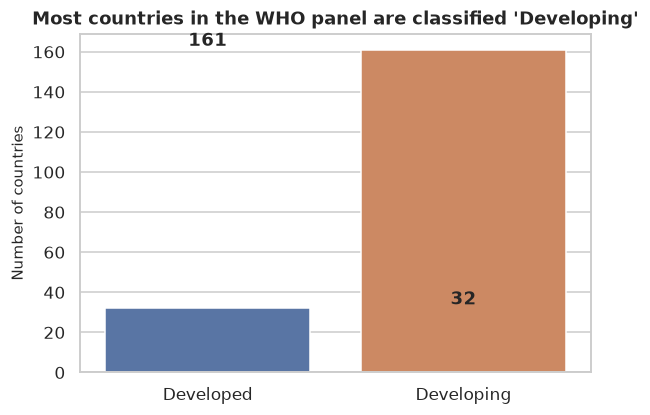

In [7]:
# --- Nominal: development status ---
fig, ax = plt.subplots(figsize=(6, 4))
counts = df.drop_duplicates("country")["status"].value_counts()
sns.barplot(x=counts.index, y=counts.values, ax=ax,
            palette=["#4C72B0", "#DD8452"])
ax.set_title("Most countries in the WHO panel are classified 'Developing'")
ax.set_ylabel("Number of countries"); ax.set_xlabel("")
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
fig.savefig(FIG_UNI / "01_status_counts.png"); plt.show()

/var/folders/wy/yr_jlc59397gbs2vnn9t3q940000gn/T/ipykernel_40450/31168372.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="income_tier", ax=ax, palette="Blues")


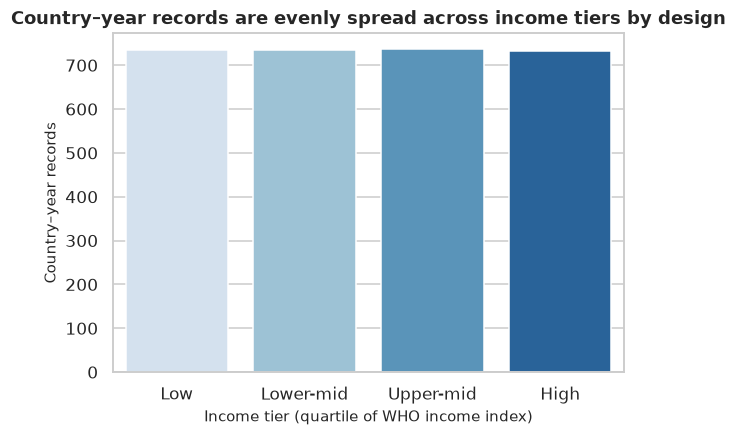

In [8]:
# --- Ordinal: income tier ---
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="income_tier", ax=ax, palette="Blues")
ax.set_title("Country–year records are evenly spread across income tiers by design")
ax.set_xlabel("Income tier (quartile of WHO income index)")
ax.set_ylabel("Country–year records")
fig.savefig(FIG_UNI / "02_income_tier.png"); plt.show()

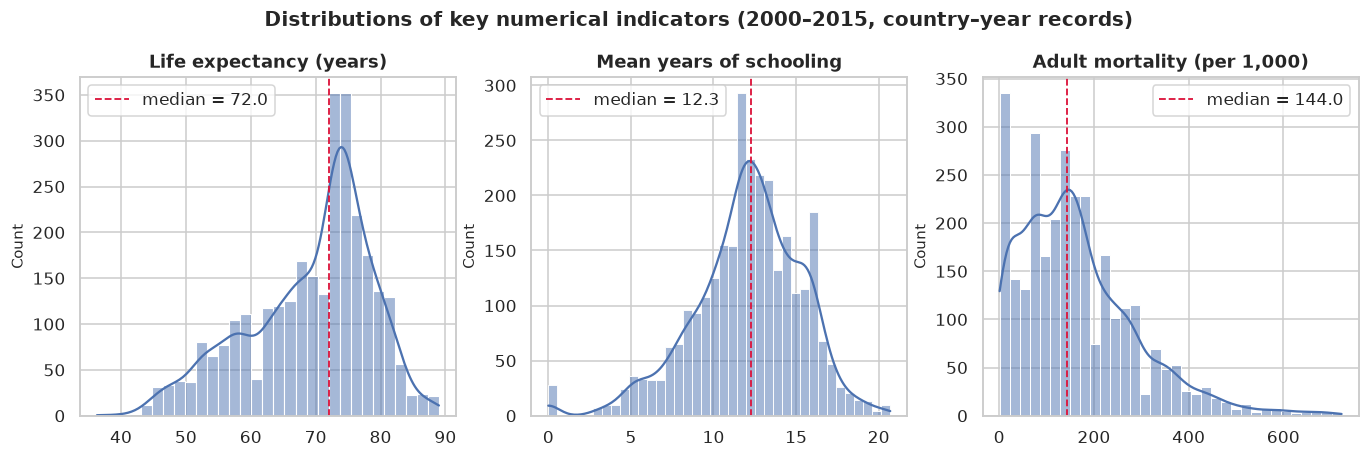

In [9]:
# --- Numerical: three key variables ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ["life_expectancy", "schooling", "adult_mortality"],
    ["Life expectancy (years)", "Mean years of schooling", "Adult mortality (per 1,000)"],
):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0", edgecolor="white")
    ax.axvline(df[col].median(), color="crimson", ls="--", lw=1.2,
               label=f"median = {df[col].median():.1f}")
    ax.set_title(title); ax.set_xlabel(""); ax.legend()
fig.suptitle("Distributions of key numerical indicators (2000–2015, country–year records)",
             y=1.03, fontsize=13, fontweight="bold")
fig.savefig(FIG_UNI / "03_numerical_distributions.png"); plt.show()

## 5. Multivariate visualisations

Chosen to cover the required data-type combinations:
- **num × num:** correlation heatmap; scatter (schooling vs life expectancy)
- **num × nominal:** box plot of life expectancy by `status`
- **num × ordinal × time:** trajectory of life expectancy by `income_tier` over years
- **num × num × nominal:** scatter GDP vs life expectancy, hue = status

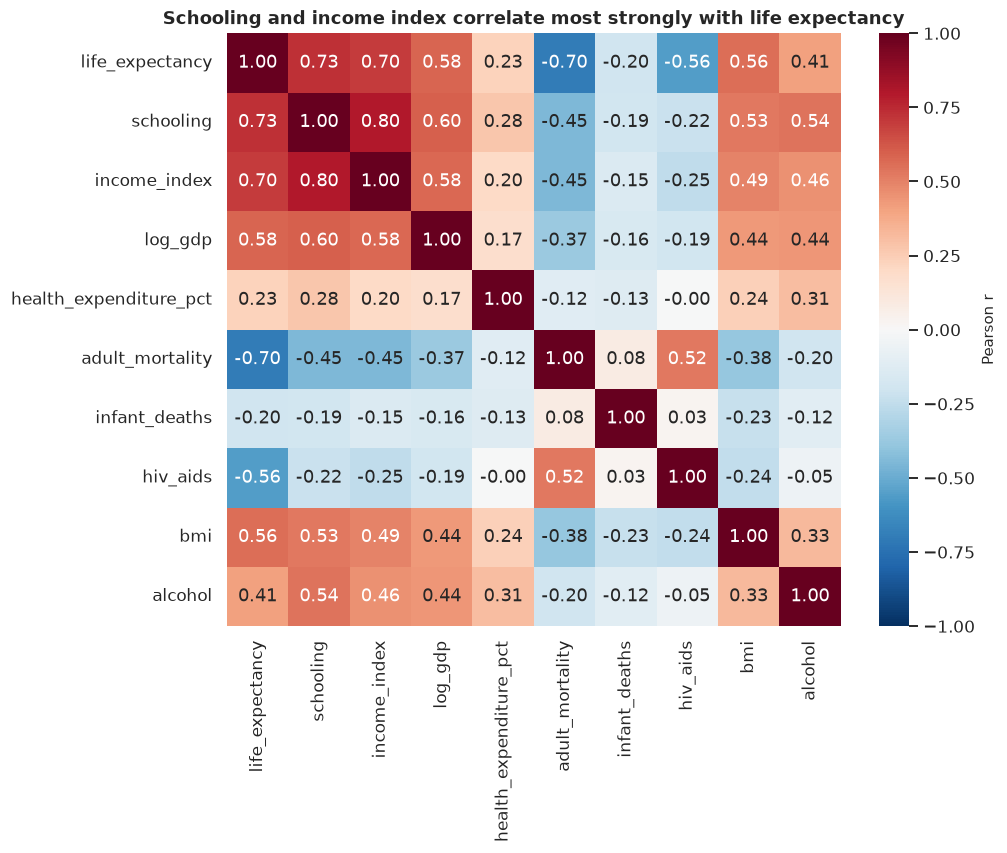

In [10]:
# --- Correlation heatmap (RQ1) ---
focus = ["life_expectancy", "schooling", "income_index", "log_gdp",
         "health_expenditure_pct", "adult_mortality", "infant_deaths",
         "hiv_aids", "bmi", "alcohol"]
corr = df[focus].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Schooling and income index correlate most strongly with life expectancy")
fig.savefig(FIG_MUL / "01_correlation_heatmap.png"); plt.show()

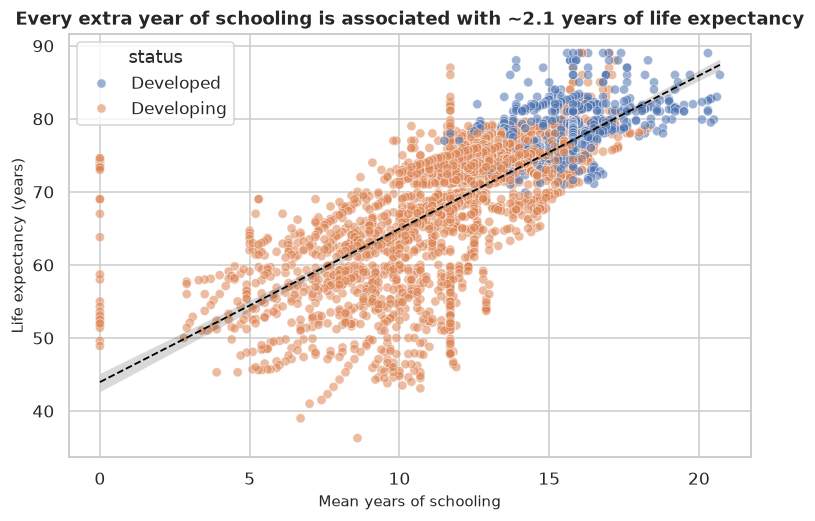

In [11]:
# --- Schooling vs Life expectancy, hue = status (RQ1 & RQ2) ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="schooling", y="life_expectancy",
                hue="status", alpha=0.55, ax=ax,
                palette={"Developed": "#4C72B0", "Developing": "#DD8452"})
sns.regplot(data=df, x="schooling", y="life_expectancy",
            scatter=False, ax=ax, color="black", line_kws={"lw": 1.2, "ls": "--"})
ax.set_title("Every extra year of schooling is associated with ~2.1 years of life expectancy")
ax.set_xlabel("Mean years of schooling"); ax.set_ylabel("Life expectancy (years)")
fig.savefig(FIG_MUL / "02_schooling_vs_le.png"); plt.show()

/var/folders/wy/yr_jlc59397gbs2vnn9t3q940000gn/T/ipykernel_40450/3042949340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="status", y="life_expectancy", ax=ax,


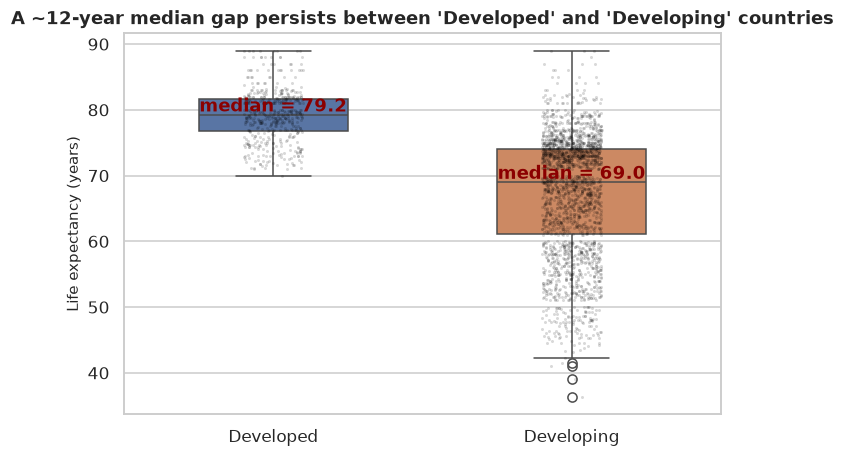

In [12]:
# --- Life expectancy by status (RQ2) ---
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x="status", y="life_expectancy", ax=ax,
            palette=["#4C72B0", "#DD8452"], width=0.5)
sns.stripplot(data=df, x="status", y="life_expectancy", ax=ax,
              color="black", alpha=0.15, size=2)
medians = df.groupby("status")["life_expectancy"].median()
for i, s in enumerate(medians.index):
    ax.text(i, medians[s]+0.5, f"median = {medians[s]:.1f}",
            ha="center", fontweight="bold", color="darkred")
ax.set_title("A ~12-year median gap persists between 'Developed' and 'Developing' countries")
ax.set_xlabel(""); ax.set_ylabel("Life expectancy (years)")
fig.savefig(FIG_MUL / "03_le_by_status.png"); plt.show()

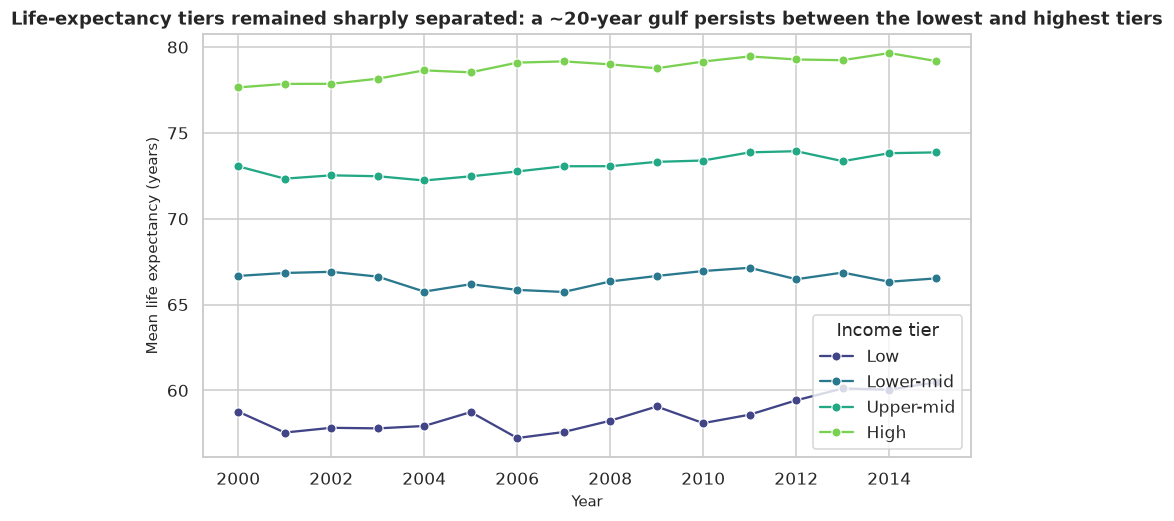

In [13]:
# --- Trajectory by income tier (RQ1 evolution over time) ---
tier_year = (df.groupby(["year", "income_tier"])["life_expectancy"]
               .mean().reset_index())
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=tier_year, x="year", y="life_expectancy",
             hue="income_tier", marker="o", ax=ax, palette="viridis")
ax.set_title("Life-expectancy tiers remained sharply separated: a ~20-year gulf persists between the lowest and highest tiers")
ax.set_xlabel("Year"); ax.set_ylabel("Mean life expectancy (years)")
ax.legend(title="Income tier", loc="lower right")
fig.savefig(FIG_MUL / "04_le_trajectory_by_tier.png"); plt.show()

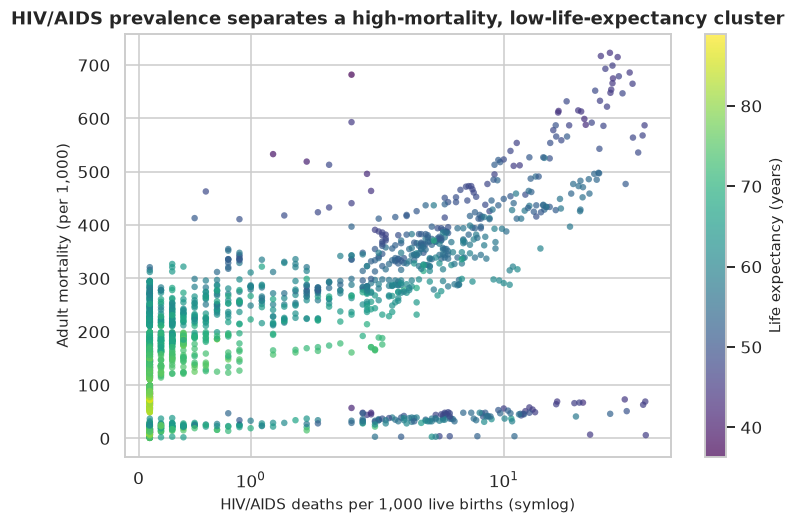

In [14]:
# --- Adult mortality clusters vs HIV/AIDS (RQ3) ---
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(df["hiv_aids"], df["adult_mortality"],
                c=df["life_expectancy"], cmap="viridis",
                s=18, alpha=0.7, edgecolor="none")
cb = plt.colorbar(sc, ax=ax); cb.set_label("Life expectancy (years)")
ax.set_xscale("symlog")
ax.set_title("HIV/AIDS prevalence separates a high-mortality, low-life-expectancy cluster")
ax.set_xlabel("HIV/AIDS deaths per 1,000 live births (symlog)")
ax.set_ylabel("Adult mortality (per 1,000)")
fig.savefig(FIG_MUL / "05_mortality_hiv.png"); plt.show()

## 6. Dashboard — multi-panel summary figure

A single at-a-glance figure for policymakers. Layout logic (information hierarchy):
- **Top-left:** headline KPI — global life expectancy trend
- **Top-right:** the inequality story — box plot by status
- **Middle-left:** *what to invest in* — top correlates
- **Middle-right:** *the education lever* — schooling vs LE
- **Bottom:** the *convergence* story — trajectories by income tier

/var/folders/wy/yr_jlc59397gbs2vnn9t3q940000gn/T/ipykernel_40450/4103610789.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="status", y="life_expectancy", ax=axB,


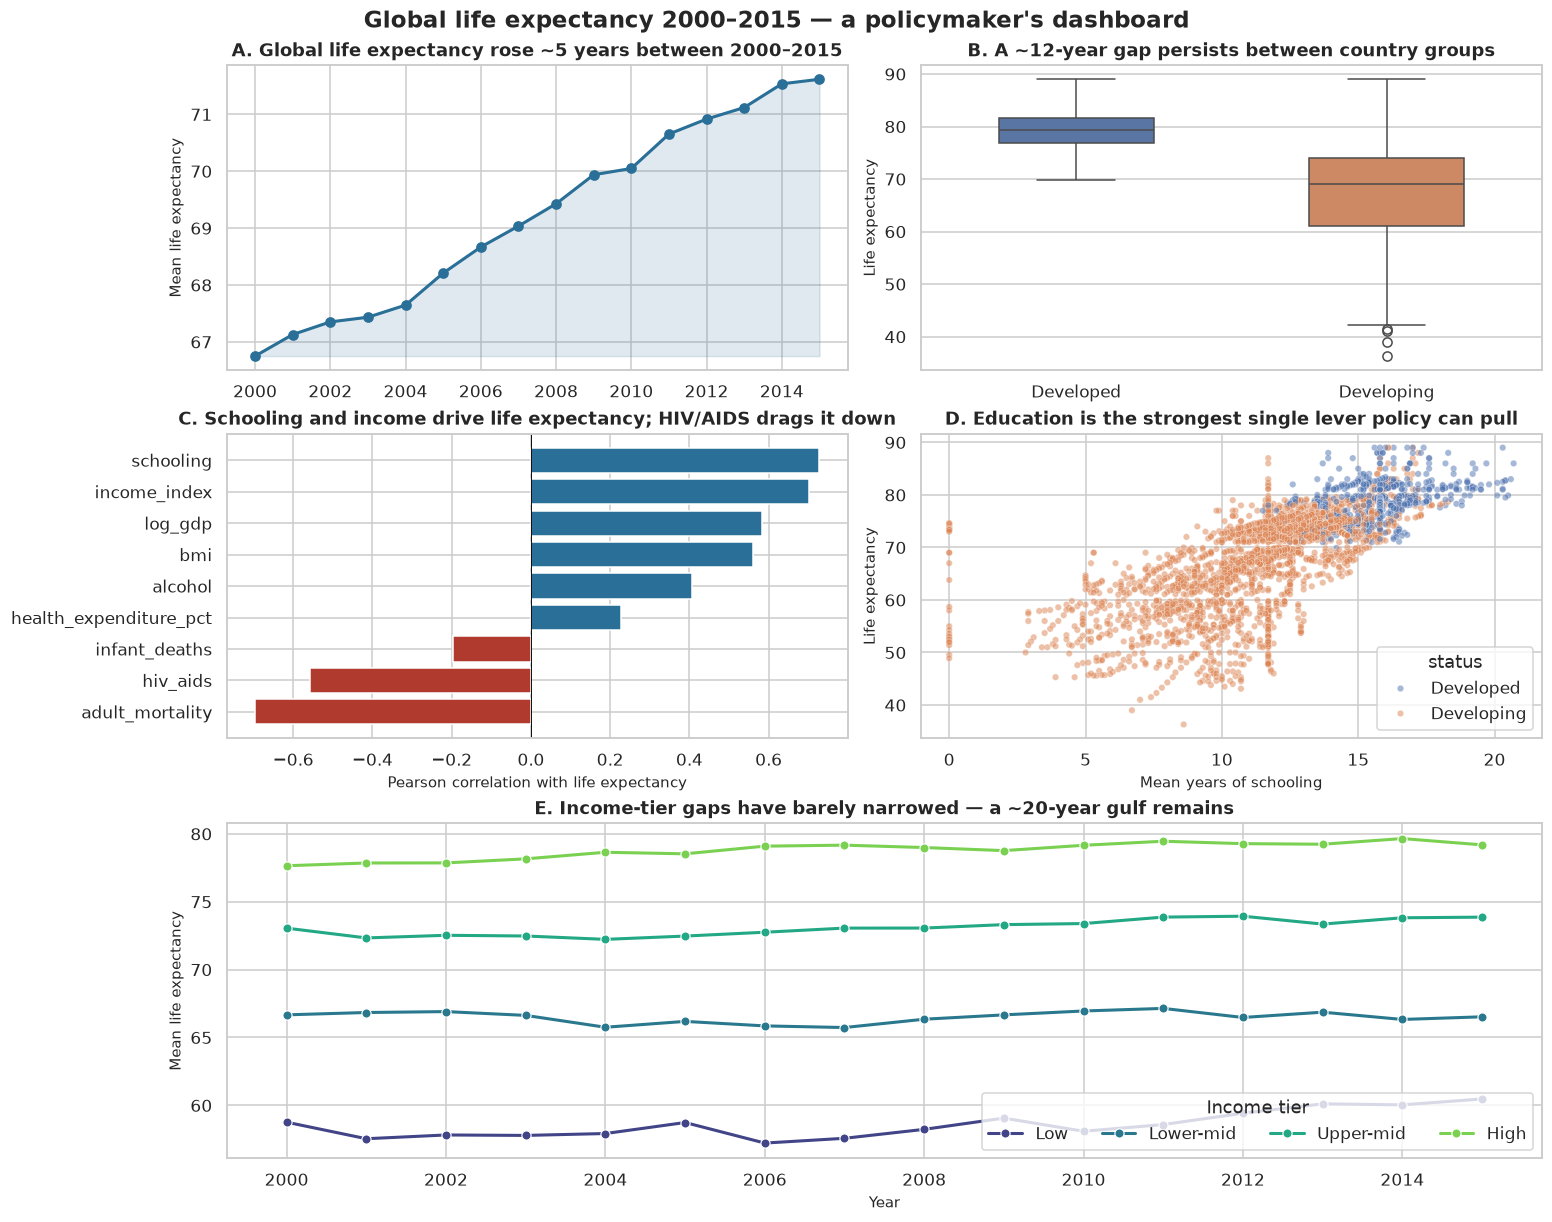

In [15]:
fig = plt.figure(figsize=(14, 11), constrained_layout=True)
gs  = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.1])

# (A) Global trend
axA = fig.add_subplot(gs[0, 0])
global_trend = df.groupby("year")["life_expectancy"].mean()
axA.plot(global_trend.index, global_trend.values, marker="o",
         color="#2A6F97", lw=2)
axA.fill_between(global_trend.index, global_trend.values,
                 global_trend.min(), alpha=0.15, color="#2A6F97")
axA.set_title("A. Global life expectancy rose ~5 years between 2000–2015")
axA.set_ylabel("Mean life expectancy")
axA.set_xlabel("")

# (B) Status gap
axB = fig.add_subplot(gs[0, 1])
sns.boxplot(data=df, x="status", y="life_expectancy", ax=axB,
            palette=["#4C72B0", "#DD8452"], width=0.5)
axB.set_title("B. A ~12-year gap persists between country groups")
axB.set_xlabel(""); axB.set_ylabel("Life expectancy")

# (C) Top correlates bar
axC = fig.add_subplot(gs[1, 0])
top_corr = (df[focus].corr()["life_expectancy"]
              .drop("life_expectancy").sort_values())
colors = ["#B03A2E" if v < 0 else "#2A6F97" for v in top_corr]
axC.barh(top_corr.index, top_corr.values, color=colors)
axC.axvline(0, color="black", lw=0.6)
axC.set_title("C. Schooling and income drive life expectancy; HIV/AIDS drags it down")
axC.set_xlabel("Pearson correlation with life expectancy")

# (D) Schooling scatter
axD = fig.add_subplot(gs[1, 1])
sns.scatterplot(data=df, x="schooling", y="life_expectancy",
                hue="status", alpha=0.5, ax=axD, s=18,
                palette={"Developed": "#4C72B0", "Developing": "#DD8452"},
                legend="brief")
axD.set_title("D. Education is the strongest single lever policy can pull")
axD.set_xlabel("Mean years of schooling"); axD.set_ylabel("Life expectancy")

# (E) Income tier trajectory (wide)
axE = fig.add_subplot(gs[2, :])
sns.lineplot(data=tier_year, x="year", y="life_expectancy",
             hue="income_tier", marker="o", ax=axE, palette="viridis", lw=2)
axE.set_title("E. Income-tier gaps have barely narrowed — a ~20-year gulf remains")
axE.set_xlabel("Year"); axE.set_ylabel("Mean life expectancy")
axE.legend(title="Income tier", ncol=4, loc="lower right")

fig.suptitle("Global life expectancy 2000–2015 — a policymaker's dashboard",
             fontsize=15, fontweight="bold")
fig.savefig(FIG_DSH / "dashboard.png"); plt.show()

## 7. Session info
For reproducibility.

In [16]:
import sys, platform
print("Python :", sys.version.split()[0])
print("OS     :", platform.platform())
for pkg in (pd, np, sns):
    print(f"{pkg.__name__:8s}: {pkg.__version__}")
import matplotlib; print(f"matplotlib: {matplotlib.__version__}")

Python : 3.12.7
OS     : macOS-15.7-arm64-arm-64bit
pandas  : 3.0.3
numpy   : 2.5.1
seaborn : 0.13.2
matplotlib: 3.11.0
